# Pipeline reproducible de sentimiento financiero

Este notebook aplica FinBERT a una muestra sintética versionada. Las etiquetas y los scores son salidas del modelo, no verdad observada ni predicciones de rentabilidad.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.sentiment import analyze_headlines, sentiment_summary

## Datos de demostración

La muestra es sintética y se incluye para que el análisis pueda repetirse sin depender de las noticias que Yahoo muestre cada día.

In [8]:
news = pd.read_csv(ROOT / 'data' / 'sample_headlines.csv')
news[['published_at', 'ticker', 'title', 'relevance']]
print(news.to_string(index=False))

ticker         published_at                                                                          title           summary      publisher  url relevance    source
  DEMO 2026-03-01T09:00:00Z           The bank reported stronger profits after lower loan-loss provisions. Synthetic example Portfolio demo  NaN   context synthetic
  DEMO 2026-03-02T09:00:00Z The company warned that liquidity may be insufficient to meet its obligations. Synthetic example Portfolio demo  NaN   context synthetic
  DEMO 2026-03-03T09:00:00Z    The central bank kept interest rates unchanged after its scheduled meeting. Synthetic example Portfolio demo  NaN   context synthetic
  TSLA 2026-03-04T09:00:00Z  Tesla reported record quarterly vehicle deliveries above market expectations. Synthetic example Portfolio demo  NaN    direct synthetic
  TSLA 2026-03-05T09:00:00Z               Tesla shares fell after the company reduced its margin guidance. Synthetic example Portfolio demo  NaN    direct synthetic
  TSLA 202

## Inferencia con FinBERT

La primera ejecución descarga `ProsusAI/finbert`. La columna `model_score` es la salida softmax asociada a la etiqueta elegida; no debe interpretarse como certeza calibrada.

In [6]:
results = analyze_headlines(news)
results[['title', 'relevance', 'model_label', 'model_score']]
print(results.to_string(index=False))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ticker         published_at                                                                          title           summary      publisher  url relevance    source                                                                  analyzed_text  translated model_label  model_score  signed_score
  DEMO 2026-03-01T09:00:00Z           The bank reported stronger profits after lower loan-loss provisions. Synthetic example Portfolio demo  NaN   context synthetic           The bank reported stronger profits after lower loan-loss provisions.       False    positive     0.953434      0.953434
  DEMO 2026-03-02T09:00:00Z The company warned that liquidity may be insufficient to meet its obligations. Synthetic example Portfolio demo  NaN   context synthetic The company warned that liquidity may be insufficient to meet its obligations.       False    negative     0.962506     -0.962506
  DEMO 2026-03-03T09:00:00Z    The central bank kept interest rates unchanged after its scheduled meeting. Syntheti

In [7]:
summary = sentiment_summary(results)
print(summary.to_string(index=False))

model_label  headlines  mean_model_score
   negative          3          0.868125
   positive          3          0.936239
    neutral          2          0.769543


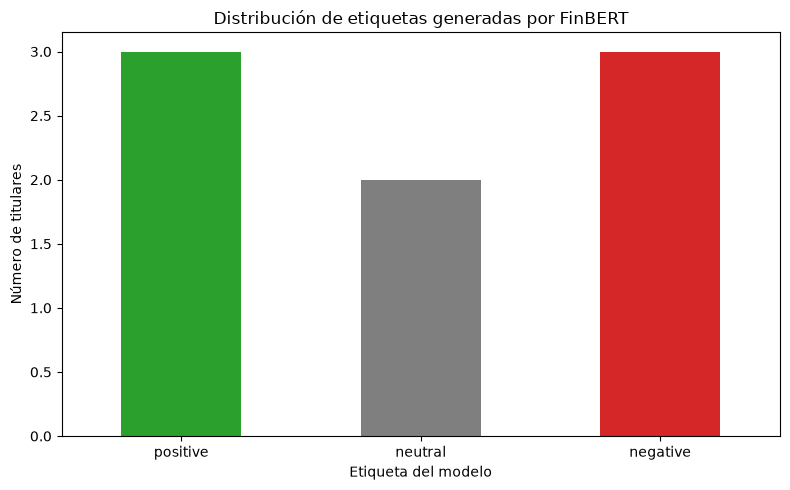

In [5]:
order = ['positive', 'neutral', 'negative']
colors = ['#2ca02c', '#7f7f7f', '#d62728']
counts = results['model_label'].value_counts().reindex(order, fill_value=0)
ax = counts.plot.bar(color=colors, figsize=(8, 5), rot=0)
ax.set_title('Distribución de etiquetas generadas por FinBERT')
ax.set_xlabel('Etiqueta del modelo')
ax.set_ylabel('Número de titulares')
plt.tight_layout();

## Interpretación y límites

- El análisis describe el tono que FinBERT asigna a cada titular.
- No mide exactitud porque la muestra no contiene etiquetas humanas de referencia.
- El sentimiento no equivale a dirección futura del precio ni constituye una recomendación de inversión.
- Las noticias de contexto deben analizarse por separado de las menciones directas a la empresa.